# Image Processing Using Opencv 
---
### Install Opencv
- Example on MacOS
```console  
$ pip3 --version
pip 24.0 from /opt/anaconda3/lib/python3.12/site-packages/pip (python 3.12)
$ python3 --version
Python 3.12.4
$ pip3 install opencv-python
Collecting opencv-python
  Downloading opencv-python-4.11.0.86.tar.gz (95.2 MB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 MB 2.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
Requirement already satisfied: numpy>=1.21.2 in /opt/anaconda3/lib/python3.12/site-packages (from opencv-python) (1.26.4)
Building wheels for collected packages: opencv-python
  Building wheel for opencv-python (pyproject.toml) ... done
  Created wheel for opencv-python: filename=opencv_python-4.11.0.86-cp312-cp312-macosx_10_16_x86_64.whl size=27595148 sha256=0fc6f3f12d5b5f0a5a54d870de9e866aaf59484b11dfcce77a8aece5a4f393e9
  Stored in directory: /Users/bshen2/Library/Caches/pip/wheels/be/bd/d5/425eca52f204ab4b1ad7ac23c79e7a0458ee178056e4350265
Successfully built opencv-python
Installing collected packages: opencv-python
Successfully installed opencv-python-4.11.0.86
```
---
### Filtering through Convolution
Let's use convolution for the following image processing:
- Edge Detection
- Feature Extraction
- Blurring &rarr; Scaling

### Import resources and display image

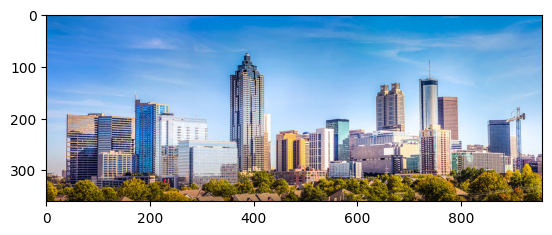

In [1]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import cv2
import numpy as np

%matplotlib inline

# Read in the image
image = mpimg.imread('building2.jpg')

plt.imshow(image)

### Convert the image to grayscale

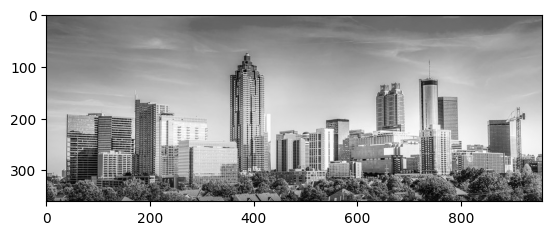

In [2]:
# Convert to grayscale for filtering
gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

plt.imshow(gray, cmap='gray')

### Convolution Through a Kernel

Image convolution is a mathematical operation where a small matrix (called a kernel or filter) slides over an image, performing element-wise multiplications and summing the results to produce a new pixel value. This process helps extract features such as edges, textures, and patterns by emphasizing specific spatial structures in the image. Convolution is widely used in image processing and deep learning, particularly in convolutional neural networks (CNNs) for feature detection.

Here we practice applying image convolution using traditional image processing operations.
1. **Select a Kernel (Filter):** Choose a small matrix (e.g., 3x3 or 5x5) with predefined values for a specific operation (e.g., edge detection, blurring).  

2. **Slide the Kernel Over the Image:** Move the kernel across the image, covering one region at a time.  

3. **Compute the Element-Wise Product:** Multiply each value in the kernel with the corresponding pixel values in the image region.  

4. **Sum the Products:** Add up all the multiplied values to obtain a single new pixel value.  

5. **Store the Result:** Place the computed value into the corresponding location in the output image.  

6. **Repeat for Entire Image:** Continue the process by shifting the kernel until every pixel has been processed.

Here is a common 3×3 kernel for edge detection, which detects edges in a specific direction, vertical and horizontal:

**Vertical Edge Detection Kernel:**
>$
K_x =
\begin{bmatrix}
-1 & 0 & 1 \\
-1 & 0 & 1 \\
-1 & 0 & 1
\end{bmatrix}
$

**Horizontal Edge Detection Kernel:**
>$
K_y =
\begin{bmatrix}
-1 & -1 & -1 \\
0 & 0 & 0 \\
1 & 1 & 1
\end{bmatrix}
$

These kernels are convolved with an image to highlight vertical and horizontal edges, respectively.

Applying a filter like this to an image is a way of **taking (an approximation) of the derivative of the image** in the x or y direction, separately. 

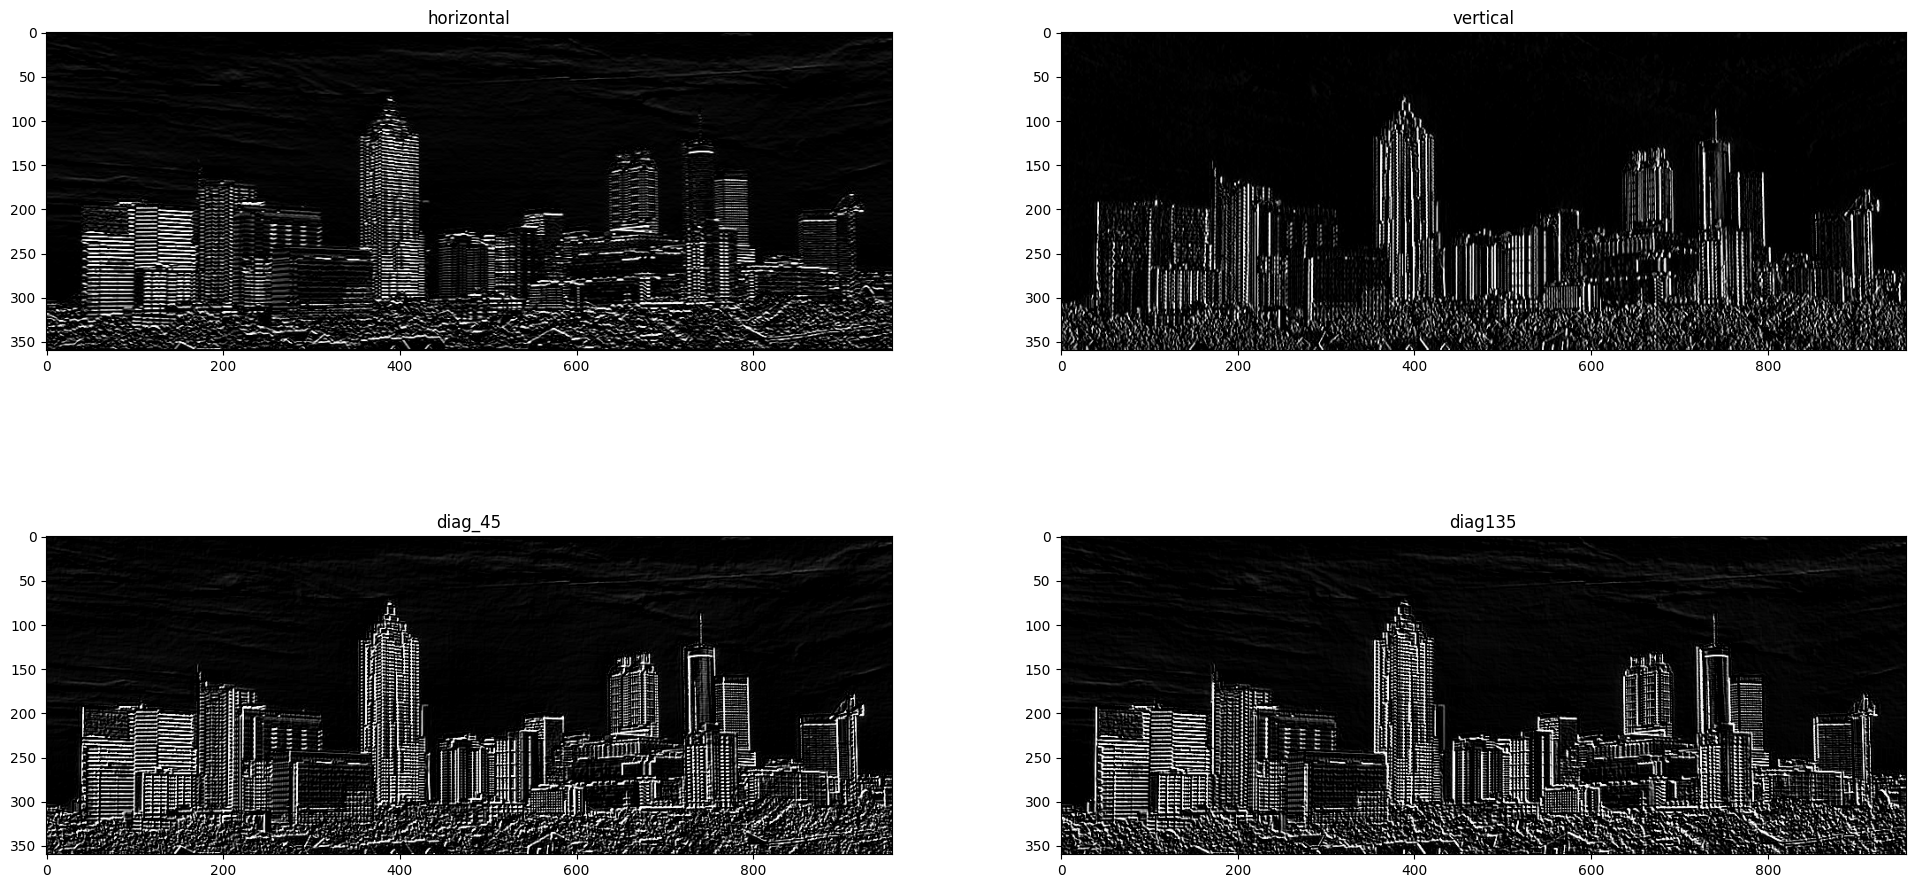

In [3]:
# Create a custom kernel

# 3x3 array for edge detection
horizon = np.array([[ -1, -1, -1], 
                    [  0,  0,  0], 
                    [  1,  1,  1]])

## TODO: Create and apply a vertical edge detection operator
vertica = np.array([[ -1, 0, 1], 
                    [ -1, 0, 1], 
                    [ -1, 0, 1]])

diag_45 = np.array([[ -2, -1, 0], 
                    [ -1,  0, 1], 
                    [  0,  1, 2]])

diag135 = np.array([[ 0, -1, -2], 
                    [ 1,  0, -1], 
                    [ 2,  1,  0]])

fig = plt.figure(figsize=(24,24))
# Filter the image using filter2D, which has inputs: (grayscale image, bit-depth, kernel)  
filtered_image = cv2.filter2D(gray, -1, horizon)
fig.add_subplot(2,2,1)
plt.imshow(filtered_image, cmap='gray')
plt.title('horizontal')

filtered_image2 = cv2.filter2D(gray, -1, vertica)
fig.add_subplot(2,2,2)
plt.imshow(filtered_image2, cmap='gray')
plt.title('vertical')

filtered_image3 = cv2.filter2D(gray, -1, diag_45)
fig.add_subplot(1,2,1)
plt.imshow(filtered_image3, cmap='gray')
plt.title('diag_45')

filtered_image4 = cv2.filter2D(gray, -1, diag135)
fig.add_subplot(1,2,2)
plt.imshow(filtered_image4, cmap='gray')
plt.title('diag135')

plt.show()

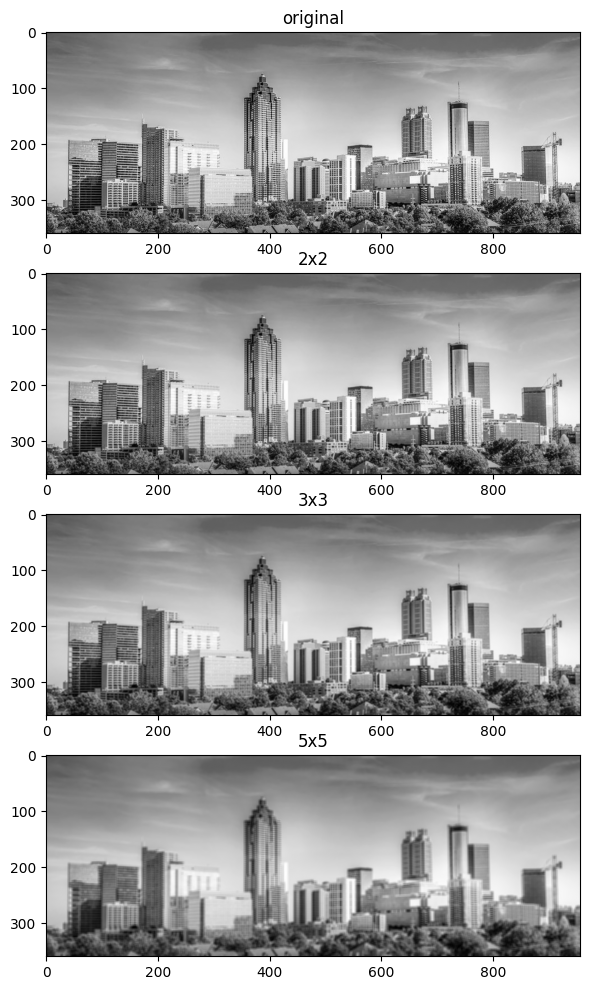

In [4]:
# Create a custom kernel for blurring

# 2x2 kernel for averaging blurring 
S2x2 = np.array([[ 1, 1], 
                 [ 1, 1]])

fig = plt.figure(figsize=(48, 12))
fig.add_subplot(4,1,1)
plt.imshow(gray, cmap='gray')
plt.title('original')

# Filter the image using filter2D, which has inputs: (grayscale image, bit-depth, kernel)  
blurred_image = cv2.filter2D(gray, -1, S2x2/4.0)
fig.add_subplot(4,1,2)
plt.imshow(blurred_image, cmap='gray')
plt.title('2x2')

#----------------NOTES-------------------
#To blur an image you create a matrix of all ones. then you divide that by the number of elements in the matrix
#----------------------------------------------------------
# TODO: blur image using a 3x3 average
#fig.add_subplot(4,1,3)
#plt.title('3x3')
# 3x3 blur

#More notes: instead of this

# S3x3 = np.ones((3,3)) I could have done 
#S3x3  = np.array([[1,1,1], [1,1,1], [1,1,1]])

#but its faster to use the ones method and initialize everything to 1 rigth away and only track the dimensions of the matrix

S3x3 = np.ones((3,3)) / 9.0
blurred_image3 = cv2.filter2D(gray, -1, S3x3)
fig.add_subplot(4,1,3)
plt.imshow(blurred_image3, cmap='gray')
plt.title('3x3')

# TODO: blur image using a 5x5 average
#fig.add_subplot(4,1,4)
#plt.title('5x5')
# 5x5 blur
S5x5 = np.ones((5,5)) / 25.0
blurred_image5 = cv2.filter2D(gray, -1, S5x5)
fig.add_subplot(4,1,4)
plt.imshow(blurred_image5, cmap='gray')
plt.title('5x5')

#Note that the bigger the matrix used the more blurry it gets, the bigger the dimensions of the matrix the more blurry it gets

plt.show()

### TODO

Other image processing/filtering you can try:
- Other Edge Detector (e.g. Sobel Operator)
A common 3×3 kernel for edge detection is the **Sobel operator**, which detects edges in a specific direction. Below are the Sobel kernels for detecting vertical and horizontal edges:

**Vertical Edge Detection Kernel:**
> $
K_x =
\begin{bmatrix}
-1 & 0 & 1 \\
-2 & 0 & 2 \\
-1 & 0 & 1
\end{bmatrix}
$

**Horizontal Edge Detection Kernel:**
> $
K_y =
\begin{bmatrix}
-1 & -2 & -1 \\
0 & 0 & 0 \\
1 & 2 & 1
\end{bmatrix}
$

These kernels are convolved with an image to highlight vertical and horizontal edges, respectively.

- Corner Detection (use the kernels we discussed in slides)
- Scaling (after the blurring, can you pick one pixel out of the following?)
  - 2x2
  - 4x4
- Use other images of your choice
- For a challenge, see if you can put the image through a series of filters: first one that blurs the image (takes an average of pixels), and then one that detects the edges.

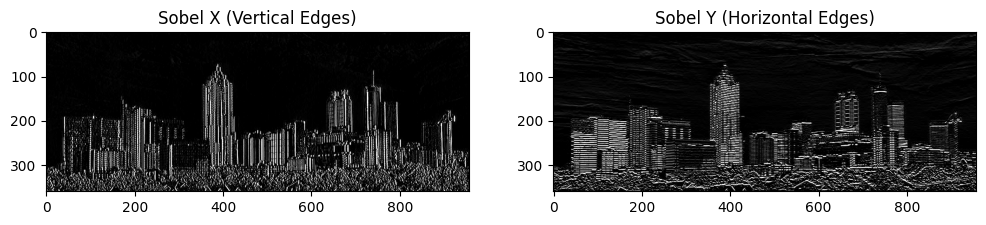

In [5]:
# Sobel filters
#sobel detects edges and smoothes noise at the same time
#the middle gradient counts more. That one is emphasized because now there is a 2 in place of the one in the middle of each matrix
#so we have a weighted gradient where the middle row/column has a higher weight
#this gives more importance to the center pixels
#this results in slightly clearer edges, making them stand out more in a subtle way
#these edges are smoother and more accurate compared to simple edge filters

sobel_x = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]])

sobel_y = np.array([[-1, -2, -1],
                    [ 0,  0,  0],
                    [ 1,  2,  1]])

sobel_x_img = cv2.filter2D(gray, -1, sobel_x)
sobel_y_img = cv2.filter2D(gray, -1, sobel_y)

fig = plt.figure(figsize=(12,6))

fig.add_subplot(1,2,1)
plt.imshow(sobel_x_img, cmap='gray')
plt.title('Sobel X (Vertical Edges)')

fig.add_subplot(1,2,2)
plt.imshow(sobel_y_img, cmap='gray')
plt.title('Sobel Y (Horizontal Edges)')

plt.show()

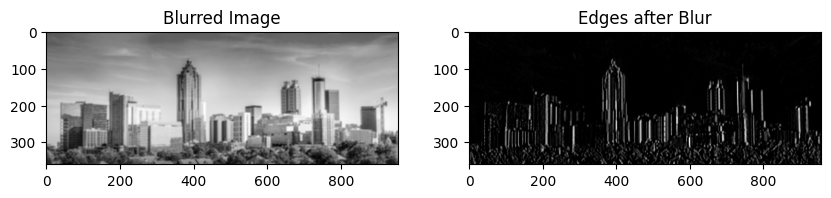

In [6]:
# Blur then edge detect
#order matters in image processing which is why preprocessing is so important
#if we blur the image first, then detect the edgees we get less noise in our edges and higher visibility resuling in a cleaner result

#first apply a blur of a 5x5 matrix to reduce noise
blur = cv2.filter2D(gray, -1, np.ones((5,5))/25.0)

#after we detect edges to get cleaner edges, here we are exracting only the vertical edges
edges = cv2.filter2D(blur, -1, sobel_x)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(blur, cmap='gray')
plt.title('Blurred Image')

plt.subplot(1,2,2)
plt.imshow(edges, cmap='gray')
plt.title('Edges after Blur')

plt.show()

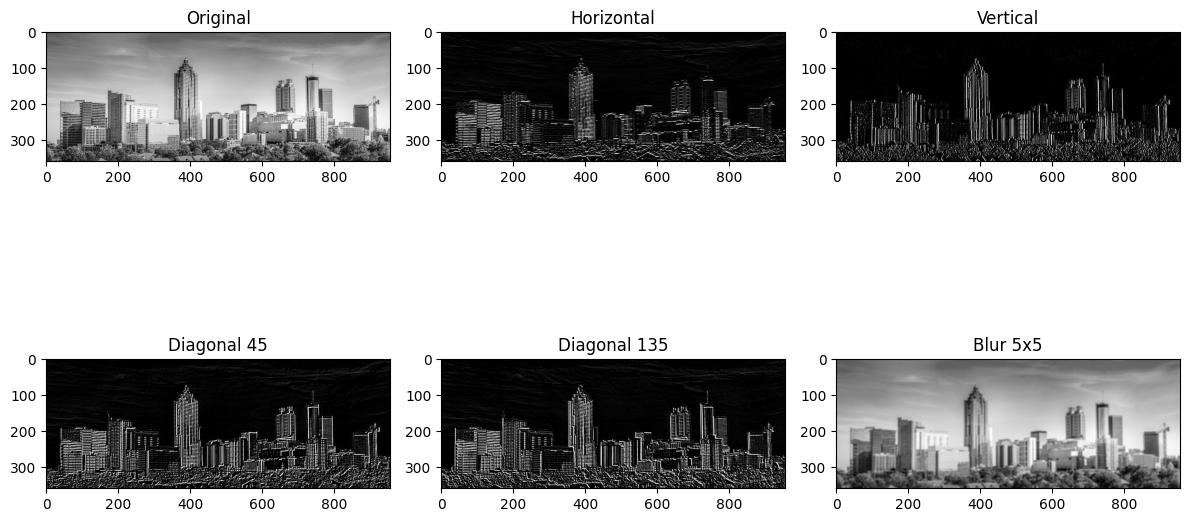

In [7]:
plt.figure(figsize=(12,8))

plt.subplot(2,3,1)
plt.imshow(gray, cmap='gray')
plt.title('Original')

plt.subplot(2,3,2)
plt.imshow(filtered_image, cmap='gray')
plt.title('Horizontal')

plt.subplot(2,3,3)
plt.imshow(filtered_image2, cmap='gray')
plt.title('Vertical')

plt.subplot(2,3,4)
plt.imshow(filtered_image3, cmap='gray')
plt.title('Diagonal 45')

plt.subplot(2,3,5)
plt.imshow(filtered_image4, cmap='gray')
plt.title('Diagonal 135')

plt.subplot(2,3,6)
plt.imshow(blurred_image5, cmap='gray')
plt.title('Blur 5x5')

plt.tight_layout()
plt.show()

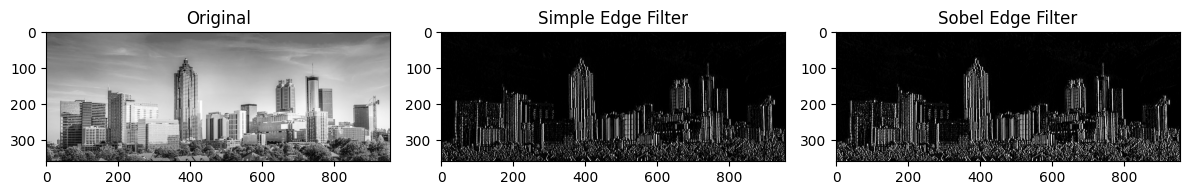

In [8]:
# Compare simple edge detection vs Sobel

# Simple vertical edge filter (you already used something like this)
simple_vertical = np.array([[-1, 0, 1],
                            [-1, 0, 1],
                            [-1, 0, 1]])

simple_edges = cv2.filter2D(gray, -1, simple_vertical)

# Sobel filter (same direction)
sobel_x = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]])

sobel_edges = cv2.filter2D(gray, -1, sobel_x)

# Plot comparison
plt.figure(figsize=(12,5))

plt.subplot(1,3,1)
plt.imshow(gray, cmap='gray')
plt.title('Original')

plt.subplot(1,3,2)
plt.imshow(simple_edges, cmap='gray')
plt.title('Simple Edge Filter')

plt.subplot(1,3,3)
plt.imshow(sobel_edges, cmap='gray')
plt.title('Sobel Edge Filter')

plt.tight_layout()
plt.show()

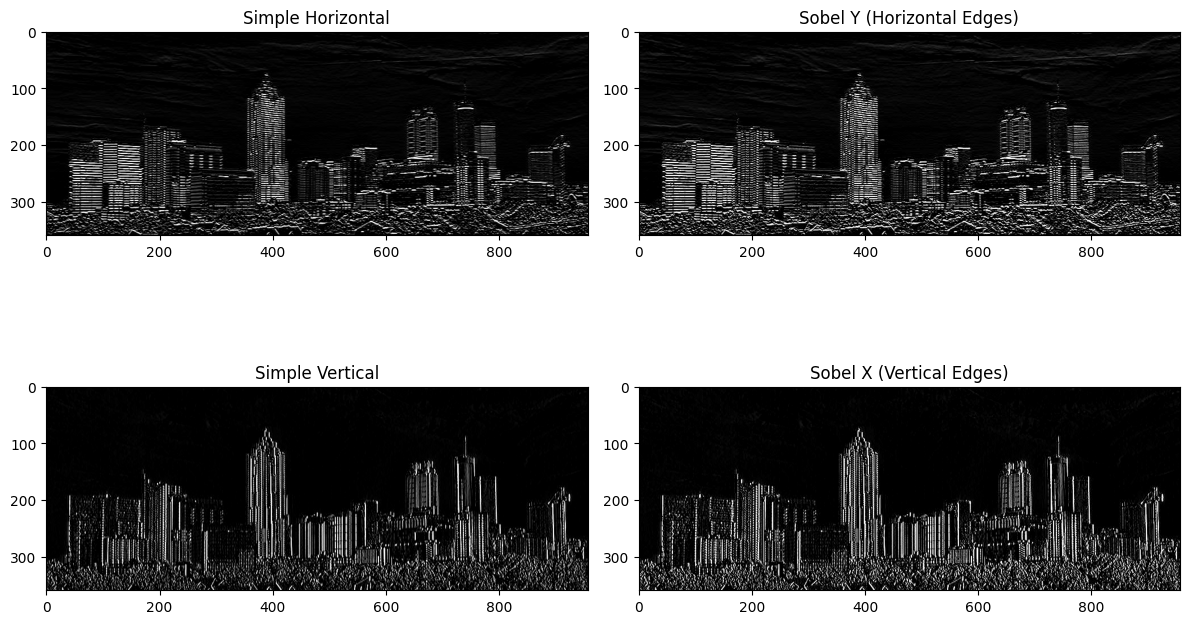

In [9]:
# Compare simple edge filters vs Sobel filters

# Simple filters (you already defined these earlier)
simple_horizontal = horizon
simple_vertical = vertica  # or rename to "vertical" if you cleaned it up

# Sobel filters
sobel_x = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]])

sobel_y = np.array([[-1, -2, -1],
                    [ 0,  0,  0],
                    [ 1,  2,  1]])

# Apply filters
simple_h_img = cv2.filter2D(gray, -1, simple_horizontal)
simple_v_img = cv2.filter2D(gray, -1, simple_vertical)

sobel_x_img = cv2.filter2D(gray, -1, sobel_x)
sobel_y_img = cv2.filter2D(gray, -1, sobel_y)

# Plot comparisons
plt.figure(figsize=(12,8))

# Horizontal comparison
plt.subplot(2,2,1)
plt.imshow(simple_h_img, cmap='gray')
plt.title('Simple Horizontal')

plt.subplot(2,2,2)
plt.imshow(sobel_y_img, cmap='gray')
plt.title('Sobel Y (Horizontal Edges)')

# Vertical comparison
plt.subplot(2,2,3)
plt.imshow(simple_v_img, cmap='gray')
plt.title('Simple Vertical')

plt.subplot(2,2,4)
plt.imshow(sobel_x_img, cmap='gray')
plt.title('Sobel X (Vertical Edges)')

plt.tight_layout()
plt.show()